# 1. Import libaries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from scipy.spatial import ConvexHull

# 2. Rescaling

In [3]:
# Load rfm data
raw_rfm = pd.read_parquet("data/staging/the_complete_journey_rfm_no_outlier.parquet", engine= "pyarrow")
raw_rfm.head()

,household_key,recency,frequency,monetary
0,1,6,86,4330.16
1,3,9,46,2519.75
2,5,9,39,757.07
3,6,5,242,5613.98
4,7,3,59,3350.77


In [4]:
# Clone the RFM values to a new dataframe
rfm_df = raw_rfm[[ 'recency', 'frequency', 'monetary']].copy()

# Instantiate
scaler = StandardScaler()

# Fit_transform
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled

array([[-0.38288671, -0.05261494,  1.01279346],
       [-0.06642417, -0.71831957,  0.02102064],
       [-0.06642417, -0.83481788, -0.94460489],
       ...,
       [-0.80483676,  1.32872218,  0.02764374],
       [-0.69934924, -0.13582802,  0.25402351],
       [-0.59386173,  0.18038169,  1.08492449]], shape=(1920, 3))

In [5]:
# Convert to dataframe
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ['recency', 'frequency', 'monetary']
rfm_df_scaled.head()

,recency,frequency,monetary
0,-0.382887,-0.052615,1.012793
1,-0.066424,-0.718320,0.021021
2,-0.066424,-0.834818,-0.944605
3,-0.488374,2.543633,1.716091
4,-0.699349,-0.501966,0.476267


# 3. Hopkin Statistics

In [6]:
# snipset of the Hopkins statistic function to find if the dataset is suitable for clustering or not
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
import numpy as np
from math import isnan

def hopkins(X):
    d = X.shape[1]
    #d = len(vars) # columns
    n = len(X) # rows
    m = int(0.1 * n) 
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)
 
    rand_X = sample(range(0, n, 1), m)
 
    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
 
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0
 
    return H

In [7]:
# Pass a dataframe to the Hopkins statistic
hopkins(rfm_df_scaled)

np.float64(0.8460111251985416)

> Datasets show strong cluster tendency

# 4. KMeans Clustering

In [8]:
# Pick number of clusters
k=5

# final model with k
kmeans = KMeans(n_clusters=k, max_iter=50, random_state=42)
kmeans.fit(rfm_df_scaled)

# Get cluster labels
cluster_labels = kmeans.labels_

In [9]:
len(rfm_df), len(cluster_labels)

(1920, 1920)

In [10]:
# assign the label
rfm_df['cluster_id'] = cluster_labels
rfm_df.head()

,recency,frequency,monetary,cluster_id
0,6,86,4330.16,1
1,9,46,2519.75,2
2,9,39,757.07,2
3,5,242,5613.98,0
4,3,59,3350.77,4


In [11]:
# Return multiple kmeans cluster
for k in range(3, 11):  # 3 → 10
    kmeans = KMeans(n_clusters=k, max_iter=50, random_state=42)
    kmeans.fit(rfm_df_scaled)
    
    rfm_df[f'kmeans_{k}_cluster_id'] = kmeans.labels_

rfm_df.head()

,recency,frequency,monetary,cluster_id,kmeans_3_cluster_id,kmeans_4_cluster_id,kmeans_5_cluster_id,kmeans_6_cluster_id,kmeans_7_cluster_id,kmeans_8_cluster_id,kmeans_9_cluster_id,kmeans_10_cluster_id
0,6,86,4330.16,1,0,1,1,1,6,0,7,9
1,9,46,2519.75,2,2,2,2,2,1,1,1,1
2,9,39,757.07,2,2,2,2,2,2,3,8,8
3,5,242,5613.98,0,0,0,0,0,0,5,5,0
4,3,59,3350.77,4,2,1,4,4,1,1,1,3


# 5. Visualize Kmeans Clustering

In [12]:
# Set theme
sns.set_theme(style="whitegrid")

In [13]:
def plot_rfm_clusters(
    df,
    recency_col,
    frequency_col,
    monetary_col,
    cluster_col,
    ax=None
):

    # Colors
    unique_segments = sorted(df[cluster_col].unique())
    cmap = plt.colormaps.get_cmap('Set3')
    colors = [cmap(i / len(unique_segments)) for i in range(len(unique_segments))]
    segment_colors = {seg: colors[i] for i, seg in enumerate(unique_segments)}

    # Summary (counts + pct)
    segment_summary = (
        df[cluster_col]
        .value_counts()
        .rename_axis('cluster_id')
        .reset_index(name='count')
    )

    segment_summary['percentage'] = (
        segment_summary['count'] / segment_summary['count'].sum() * 100
    ).round(0)

    # Axis
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))

    # Plot convex hull zones
    for seg, group in df.groupby(cluster_col):

        points = group[[recency_col, frequency_col]].values

        if len(points) >= 3:
            hull = ConvexHull(points)
            polygon = plt.Polygon(
                points[hull.vertices],
                facecolor=segment_colors[seg],
                alpha=0.6,
                edgecolor="k"
            )
            ax.add_patch(polygon)

        # Cluster centroid
        cx = group[recency_col].mean()
        cy = group[frequency_col].mean()

        row = segment_summary.loc[segment_summary['cluster_id'] == seg].iloc[0]

        ax.text(
            cx, cy,
            f"Cluster {seg}\n{int(row['count']):,} ({int(row['percentage'])}%)",
            ha='center',
            va='center',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )

    ax.set_xlabel(recency_col)
    ax.set_ylabel(frequency_col)
    ax.set_title("RFM Clusters")
    ax.autoscale()

    return ax

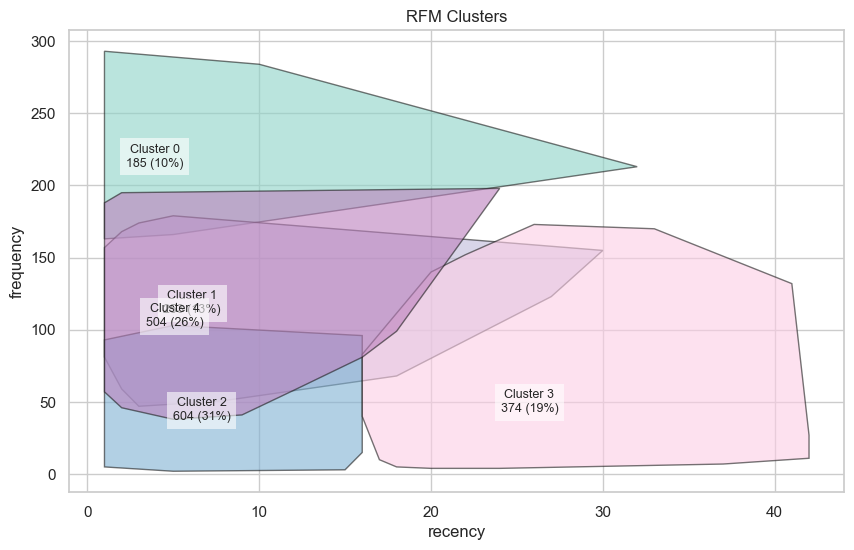

In [14]:
fig, ax = plt.subplots(figsize=(10,6))
plot_rfm_clusters(rfm_df, 'recency', 'frequency', 'monetary', 'kmeans_5_cluster_id', ax=ax)
plt.show()

# 6. Visual all viable RF Segments

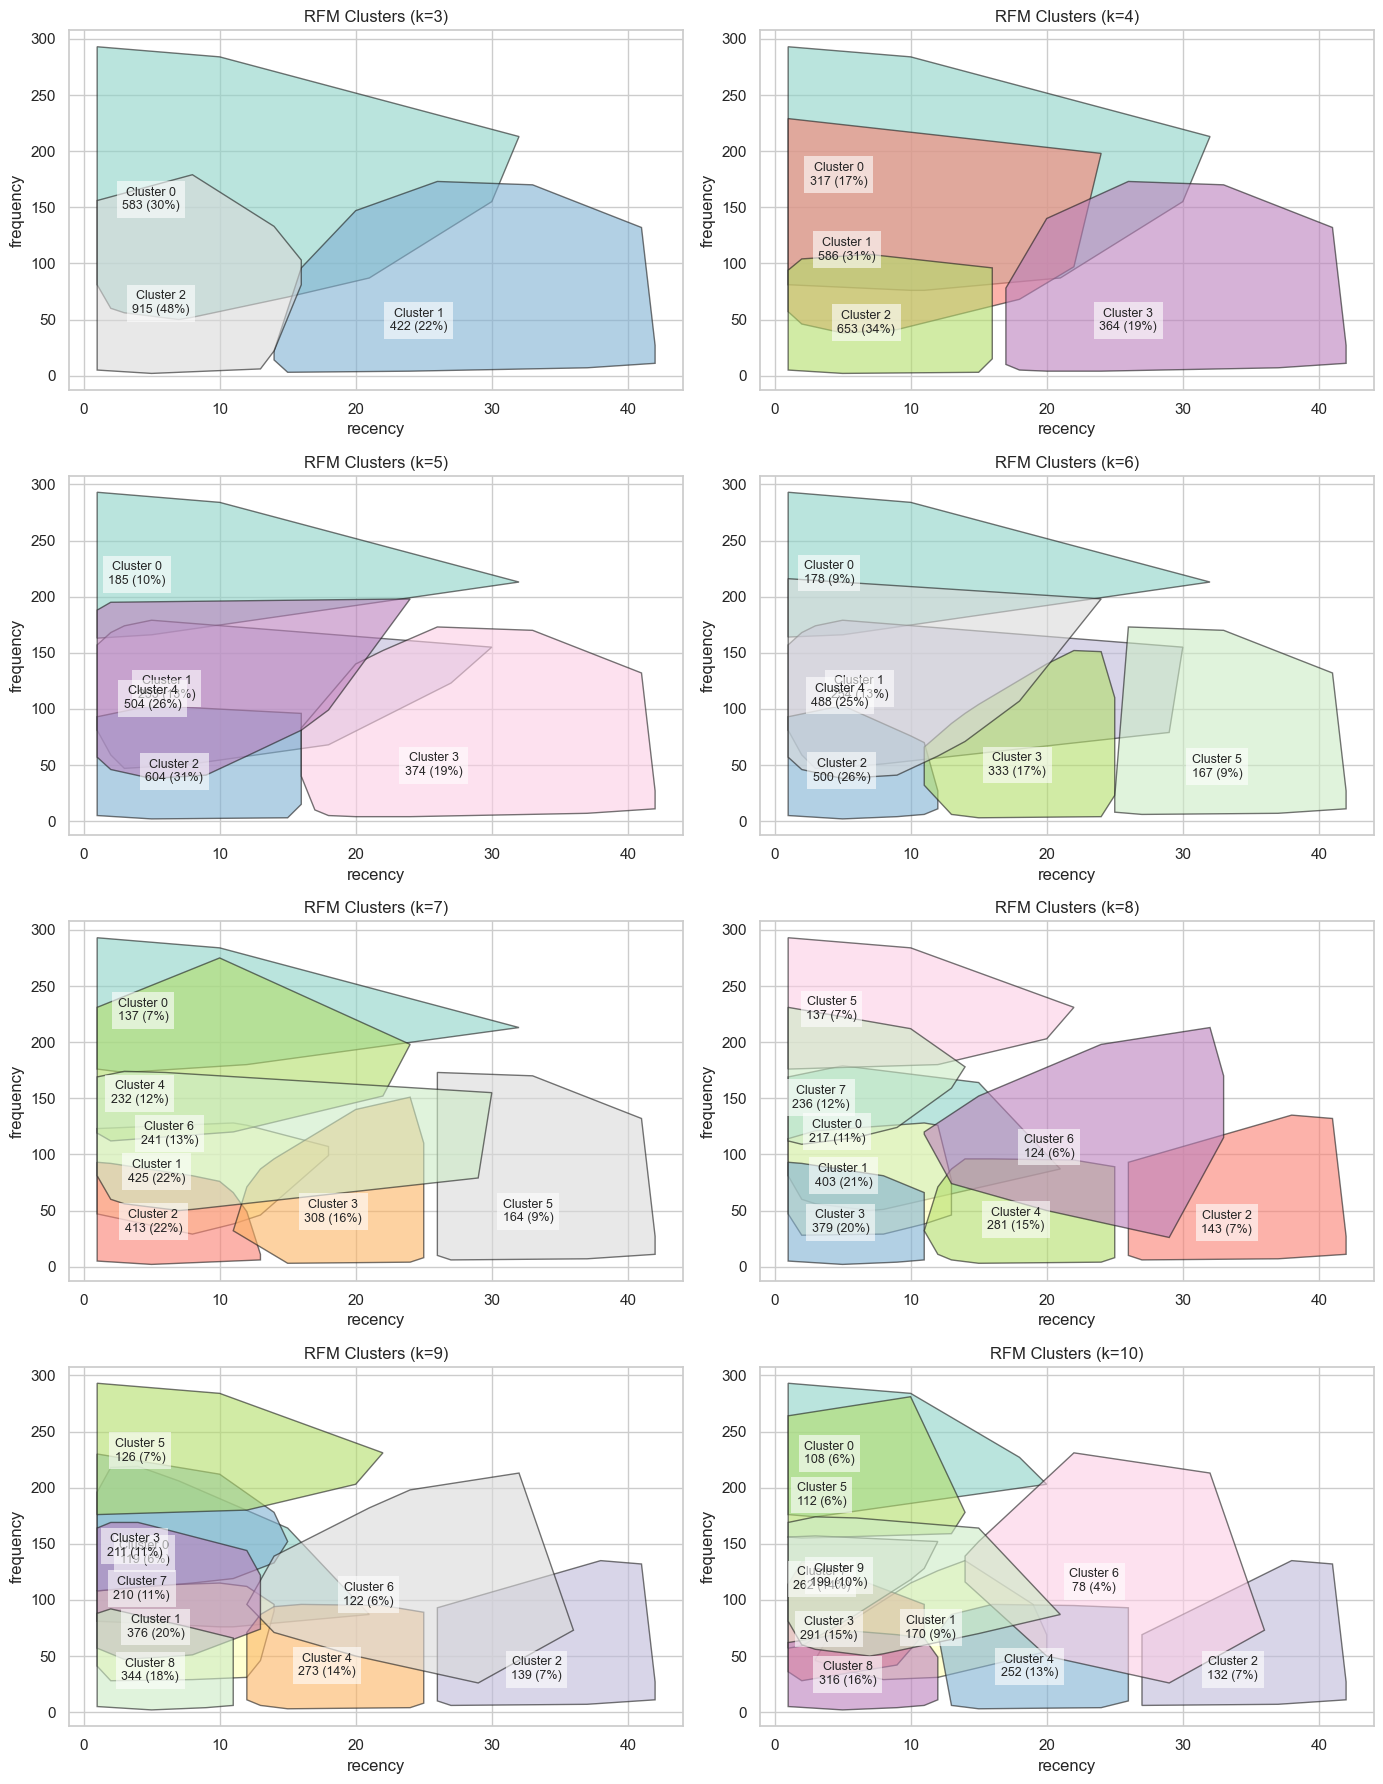

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, k in enumerate(range(3, 11)):
    
    plot_rfm_clusters(
        rfm_df,
        recency_col='recency',
        frequency_col='frequency',
        monetary_col='monetary',
        cluster_col=f'kmeans_{k}_cluster_id',
        ax=axes[i]
    )
    
    axes[i].set_title(f'RFM Clusters (k={k})')

plt.tight_layout()
plt.show()

> The 2d graph alone is not enough to analyze the R-F-M absolute values

# 7. Analyze R-F-M of each segments

In [16]:
def plot_rfm_cluster_profiles(
    df,
    recency_col,
    frequency_col,
    monetary_col,
    cluster_col,
    axes=None
):

    summary = (
        df.groupby(cluster_col)[[recency_col, frequency_col, monetary_col]]
        .mean()
        .reset_index()
        .sort_values(cluster_col)
    )

    clusters = summary[cluster_col].astype(str)
    n_clusters = len(summary)

    # Adaptive height
    height = max(3, n_clusters * 0.6)

    if axes is None:
        fig, axes = plt.subplots(1, 3, figsize=(12, height), sharey=True)

    metrics = [recency_col, frequency_col, monetary_col]

    for i, metric in enumerate(metrics):

        bars = axes[i].barh(clusters, summary[metric])

        axes[i].set_xlabel(metric)
        axes[i].grid(axis='x', linestyle='--', alpha=0.4)

        for bar in bars:
            width = bar.get_width()
            axes[i].text(
                width,
                bar.get_y() + bar.get_height()/2,
                f"{width:.2f}",
                va="center",
                ha="left",
                fontsize=8
            )

    axes[0].set_ylabel("Cluster")

    return axes

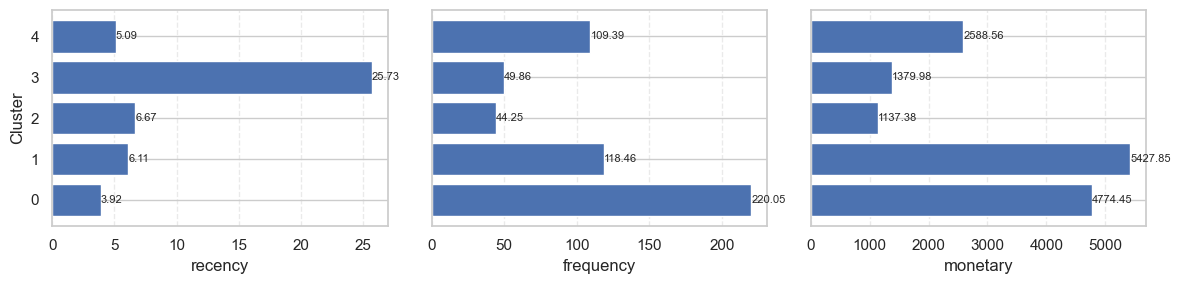

In [17]:
plot_rfm_cluster_profiles(
    rfm_df,
    recency_col="recency",
    frequency_col="frequency",
    monetary_col="monetary",
    cluster_col="kmeans_5_cluster_id",
)

plt.tight_layout()
plt.show()

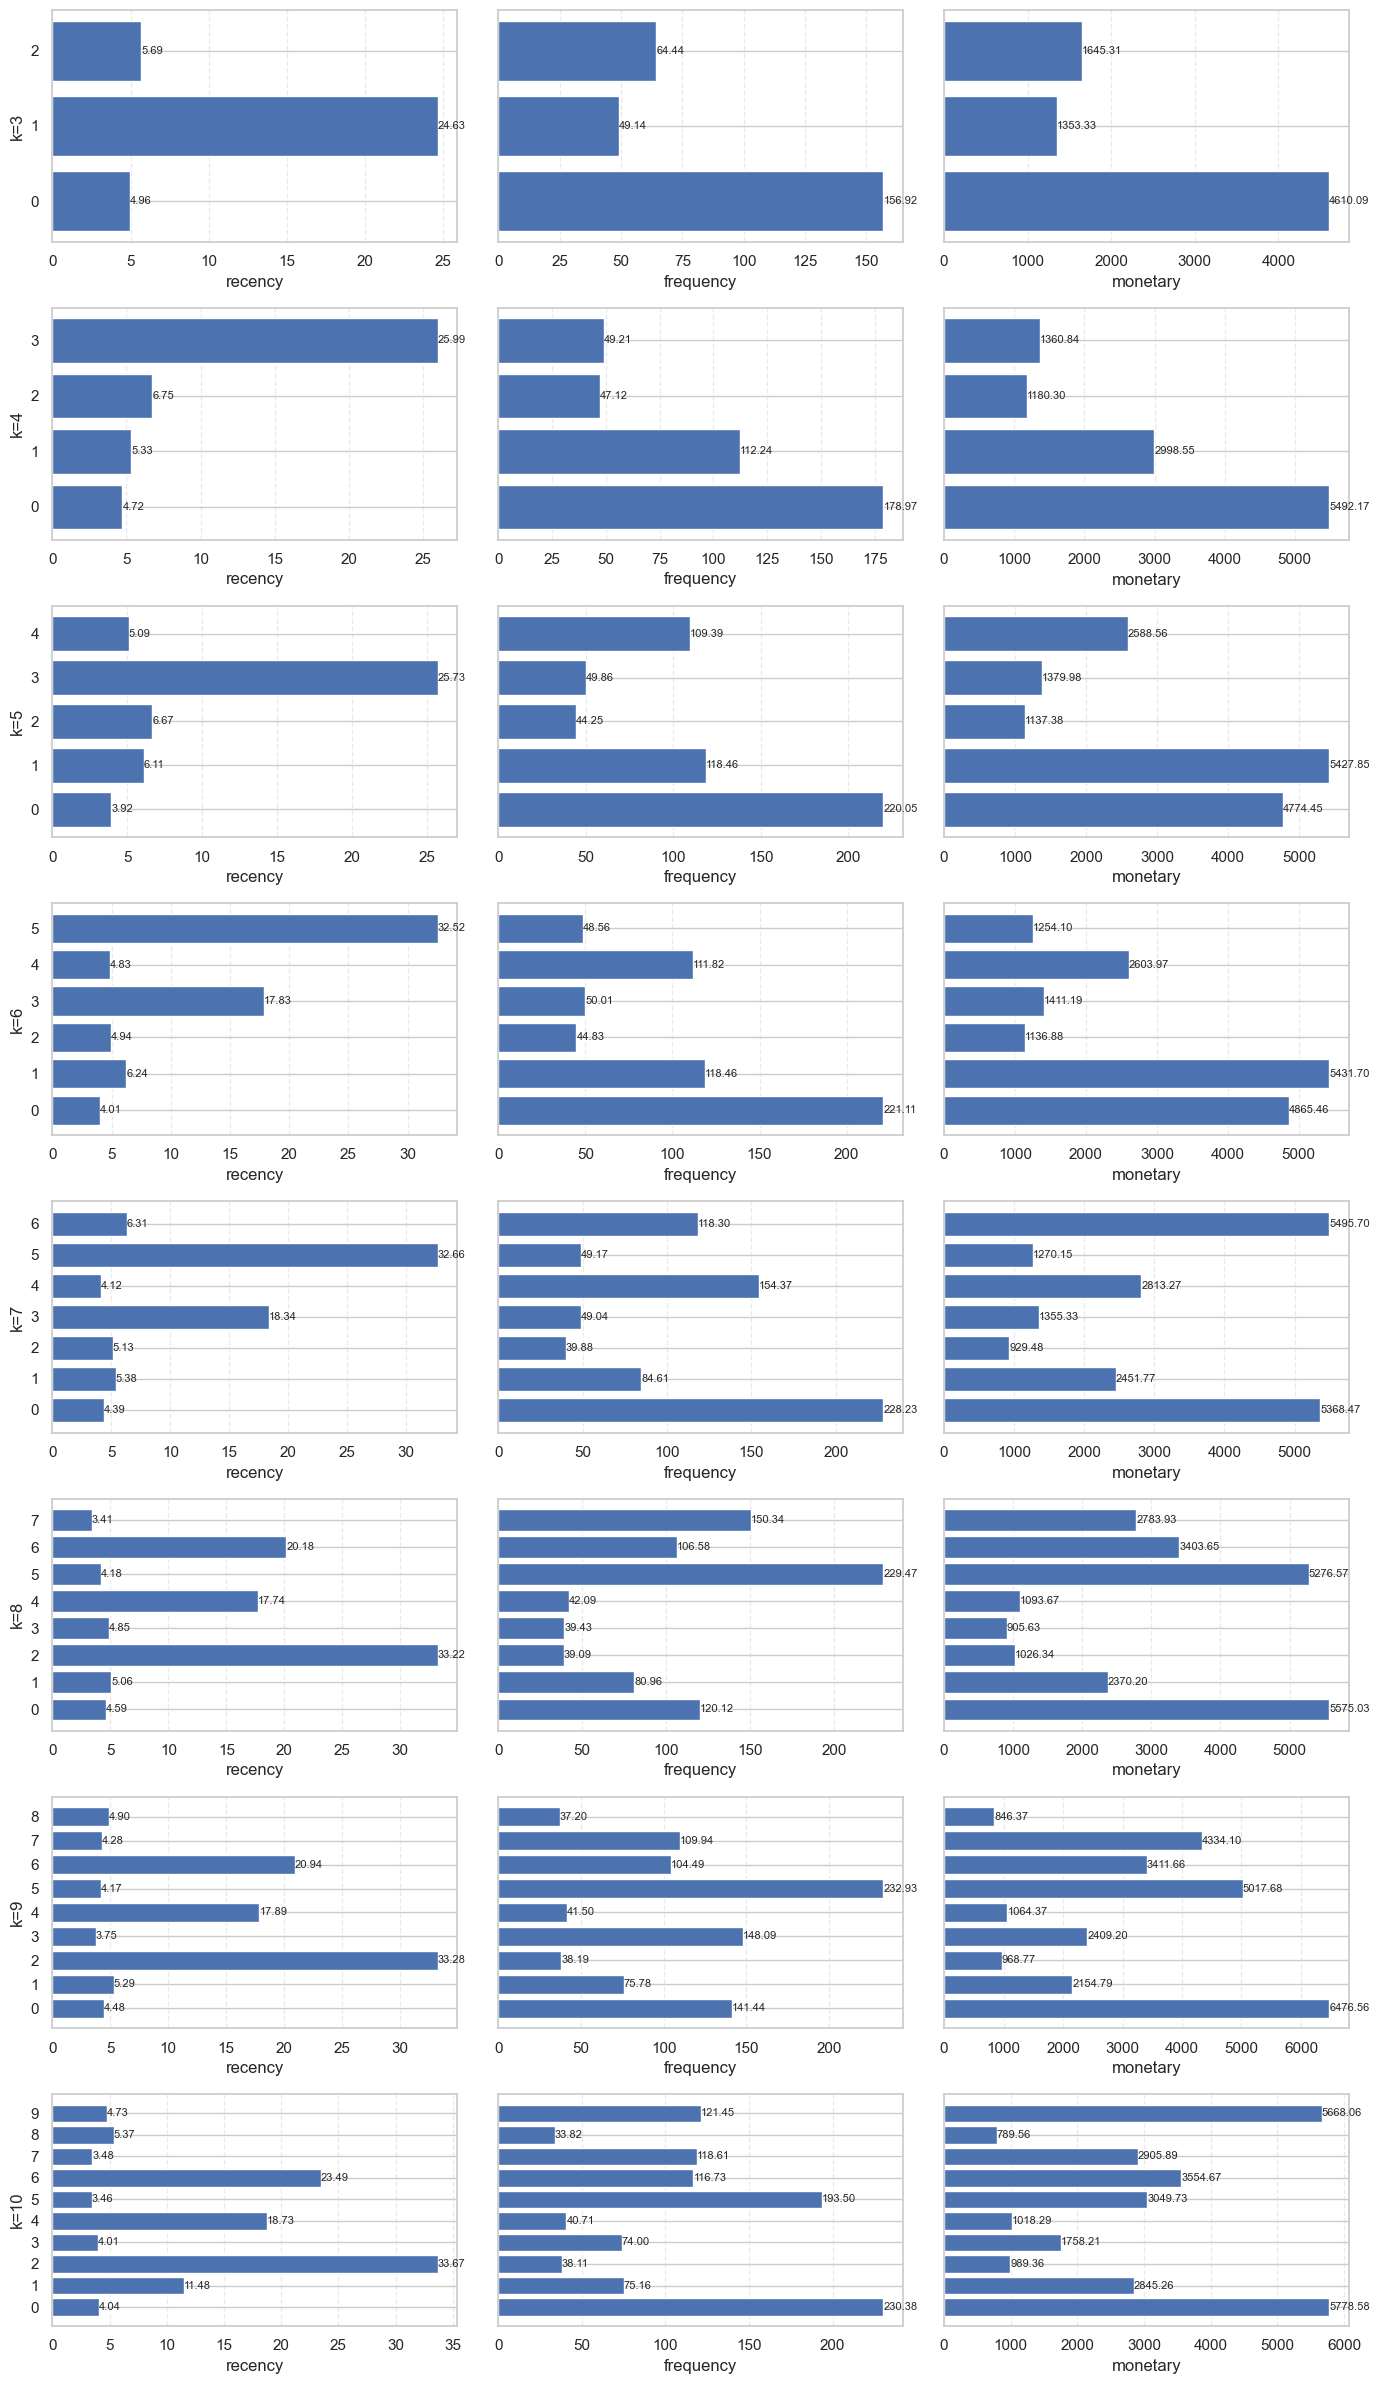

In [18]:
fig, axes = plt.subplots(8, 3, figsize=(14, 24), sharey='row')

for i, k in enumerate(range(3, 11)):

    plot_rfm_cluster_profiles(
        rfm_df,
        recency_col="recency",
        frequency_col="frequency",
        monetary_col="monetary",
        cluster_col=f"kmeans_{k}_cluster_id",
        axes=axes[i]
    )

    axes[i,0].set_ylabel(f"k={k}")

plt.tight_layout()
plt.show()

# 8. Evaluate clusters

In [19]:
scores = []

for k in range(3, 11):
    labels = rfm_df[f'kmeans_{k}_cluster_id']
    
    scores.append({
        "k": k,
        "silhouette": silhouette_score(rfm_df_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(rfm_df_scaled, labels),
        "davies_bouldin": davies_bouldin_score(rfm_df_scaled, labels)
    })

scores_df = pd.DataFrame(scores)
scores_df

,k,silhouette,calinski_harabasz,davies_bouldin
0,3,0.385497,1579.928019,0.893303
1,4,0.330160,1454.703576,1.026199
2,5,0.327838,1364.067826,0.998951
3,6,0.325317,1332.278660,1.024476
4,7,0.304469,1272.374590,1.049532
5,8,0.317863,1302.163084,0.950546
6,9,0.305692,1257.026082,0.977182
7,10,0.288588,1175.048834,1.016361


> From a pure clustering quality perspective, k=3 result in the best KMeans clustering. However, RFM segmentation is also business-driven, with 5 or more segments is needed for better targenting.

> k = 5,6,8 have good evaluation scores while still maintaining good business separation.

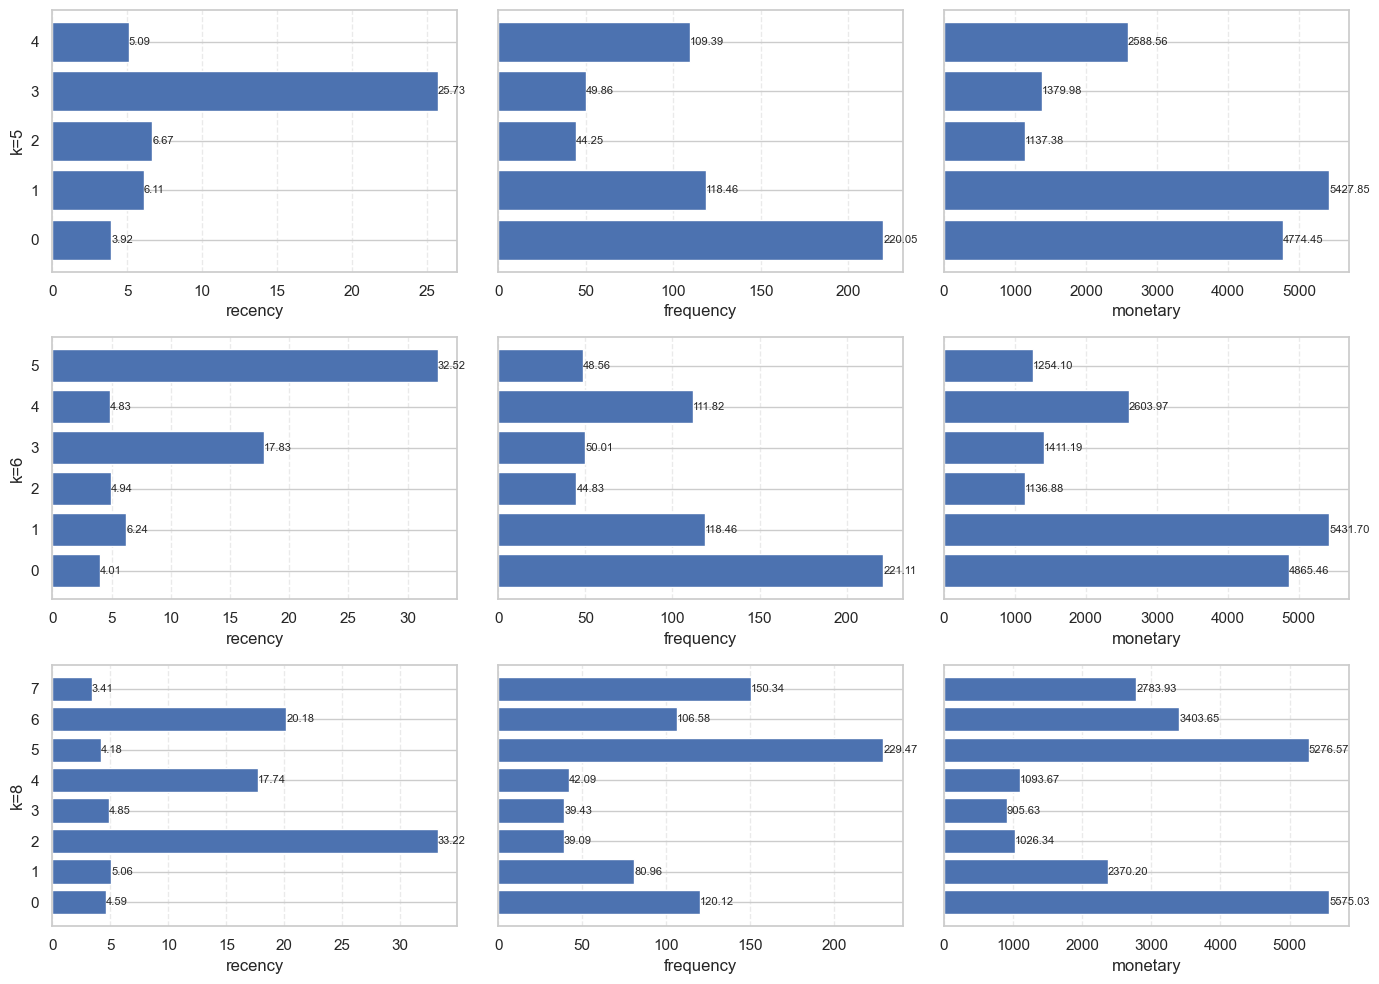

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey='row')

for i, k in enumerate([5,6,8]):

    plot_rfm_cluster_profiles(
        rfm_df,
        recency_col="recency",
        frequency_col="frequency",
        monetary_col="monetary",
        cluster_col=f"kmeans_{k}_cluster_id",
        axes=axes[i]
    )

    axes[i,0].set_ylabel(f"k={k}")

plt.tight_layout()
plt.show()

In [21]:
def plot_rfm_cluster_heatmap(
    df,
    recency_col,
    frequency_col,
    monetary_col,
    cluster_col,
    ax=None
):

    summary = (
        df.groupby(cluster_col)[[recency_col, frequency_col, monetary_col]]
        .mean()
        .sort_index()
    )

    # normalize for comparability
    scaler = StandardScaler()
    scaled = scaler.fit_transform(summary)

    scaled_df = pd.DataFrame(
        scaled,
        index=summary.index,
        columns=[recency_col, frequency_col, monetary_col]
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, max(3, len(summary)*0.5)))

    sns.heatmap(
        scaled_df,
        annot=True,
        cmap="RdYlBu_r",
        center=0,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(f"Cluster Profiles ({cluster_col})")
    ax.set_ylabel("Cluster")
    ax.set_xlabel("RFM Metric")

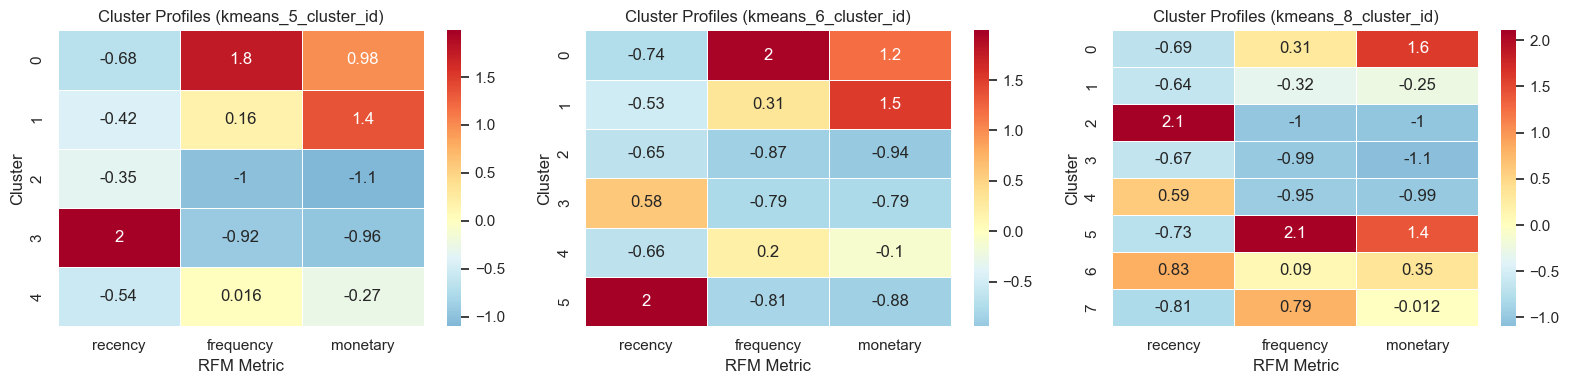

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, k in enumerate([5, 6, 8]):
    plot_rfm_cluster_heatmap(
        rfm_df,
        recency_col="recency",
        frequency_col="frequency",
        monetary_col="monetary",
        cluster_col=f"kmeans_{k}_cluster_id",
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

In [23]:
rfm_df['kmeans_8_cluster_id'].value_counts(normalize=True)

kmeans_8_cluster_id
1    0.209896
3    0.197396
4    0.146354
7    0.122917
0    0.113021
2    0.074479
5    0.071354
6    0.064583
Name: proportion, dtype: float64

> Smallest cluster consists of 6~7% of customers

# 9. Interpret the clusters

> Clusters of KMeans k = 8
- `0` : purchase very recent, with medium frequency and high LTV
- `1` : very recent, with medium both frequency and LTV
- `2` : purchase very long ago, with low both frequency and LTV
- `3` : very recent, with low both frequency and LTV
- `4` : purchase not too long ago, but low both frequency and LTV
- `5` : very recent, with high frequency and LTV
- `6` : purchase not too long ago, with medium both frequency and LTV
- `7` : very recent, with medium both frequency and LTV

> So we have cluster 1 & 7 kinda similar. Maybe a smaller k should provide better interpretability and more distinct segments.

> Clusters of KMeans k = 6
- `0` : purchase very recent, with very high both frequency and LTV --> "Champions"
- `1` : very recent, with medium frequency and high LTV             --> "Loyalist"
- `2` : very recent, with low both frequency and LTV                --> "New Customers"
- `3` : purchase not long ago, with low both frequency and LTV      --> "Need attention"
- `4` : very recent, with  medium both frequency and LTV            --> "Potential Loyalist"
- `5` : purchase very long ago, with low frequency and LTV          --> "Hibernating"

k = 6 provides a balance between clustering performance and business interpretability

> Clusters of KMeans k = 5
- `0` : purchase very recent, with very high both frequency and LTV --> "Champions"
- `1` : very recent, with medium frequency and high LTV             --> "Loyalist"
- `2` : very recent, with low both frequency and LTV                --> "New Customers"
- `3` : purchase very long ago, with low both frequency and LTV      --> "Hibernating"
- `4` : very recent, with  medium both frequency and LTV            --> "Potential Loyalist"

> k=5 provide similar interpretability to k=6, just with the lack of "Need  attention" cluster

--> k=6 provide the most distinct clusters, while still provide clear and meaningful target audiences.

# 9. Export the clusters id for later comparison

In [24]:
rfm_df.head()

,recency,frequency,monetary,cluster_id,kmeans_3_cluster_id,kmeans_4_cluster_id,kmeans_5_cluster_id,kmeans_6_cluster_id,kmeans_7_cluster_id,kmeans_8_cluster_id,kmeans_9_cluster_id,kmeans_10_cluster_id
0,6,86,4330.16,1,0,1,1,1,6,0,7,9
1,9,46,2519.75,2,2,2,2,2,1,1,1,1
2,9,39,757.07,2,2,2,2,2,2,3,8,8
3,5,242,5613.98,0,0,0,0,0,0,5,5,0
4,3,59,3350.77,4,2,1,4,4,1,1,1,3


In [27]:
# Map the cluster result back to the original rfm df
raw_rfm["kmeans_5_cluster_id"] = rfm_df["kmeans_5_cluster_id"]
raw_rfm["kmeans_6_cluster_id"] = rfm_df["kmeans_6_cluster_id"]
raw_rfm["kmeans_8_cluster_id"] = rfm_df["kmeans_8_cluster_id"]
raw_rfm.head()

,household_key,recency,frequency,monetary,kmeans_5_cluster_id,kmeans_6_cluster_id,kmeans_8_cluster_id
0,1,6,86,4330.16,1,1,0
1,3,9,46,2519.75,2,2,1
2,5,9,39,757.07,2,2,3
3,6,5,242,5613.98,0,0,5
4,7,3,59,3350.77,4,4,1


In [28]:
raw_rfm.to_parquet(
    "data/delivery/rfm_with_kmeans_clusters.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)